# Gradient Boosting Models - Breast Cancer Dataset

The purpose of this notebook is to study and compare the performance and behavior of the following **gradient boosting algorithms**: GBM, AdaBoost, XGboost and LightGBM.

To do this, we use the **Scikit-Learn** library for the models and the dataset, and also the **XGBoost** and **LightGBM** libraries for the respective implementations.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

import time

## 2. Load dataset

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # binary classification: malignant or benign

In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (569, 31)
Head:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

Clean dataset with **no missing values, 30 numerical features and 569 samples**.

We also notice that for the target, the mean is 0.627 meaning that ~63% of samples are class 1 (benign) and ~37% of them Class 0 (malignant). 

The **dataset is slightly imbalanced**. Not critically so, but it means that accuracy alone isn’t a sufficient metric. A model that always predicts 1 would already have 63% accuracy without learning anything.

That’s why we'll also look at precision, recall, and F1 score in the evaluation, especially for class 0 (malignant), where a false negative is clinically dangerous.

## 3. Train and test datasets

In [5]:
# Prepare the data: target variable and features
X = df.drop("target", axis=1).values # features
y = df["target"].values # target

In [6]:
# Split datasets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Models training

In [8]:
# Define the models to compare
models = {"Logistic Regression": LogisticRegression(),
          "Gradient Boosting Classifier": GradientBoostingClassifier(),
          "AdaBoost Classifier": AdaBoostClassifier(),
          "XGBoost Classifier": XGBClassifier(),
          "LightGBM Classifier": LGBMClassifier(importance_type='gain')}

In [9]:
# GridSearchCV parameters for each model
params = {
    "Gradient Boosting Classifier": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    "AdaBoost Classifier": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    },
    "XGBoost Classifier": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    "LightGBM Classifier": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5]
    }
}

In [ ]:
# Dictionnary to store the best models after tuning
best_models = {}

for name, model in models.items():
    # Check if the model has parameters to tune
    if name in params:
        print(f"Tuning {name}...")
        grid_search = GridSearchCV(estimator=model, param_grid=params[name], cv=5, n_jobs=-1, verbose=1)
        start_time = time.time()
        grid_search.fit(X_train_scaled, y_train)
        end_time = time.time()
        print(f"{name} training time: {end_time - start_time:.4f} seconds")
        best_model = grid_search.best_estimator_
        print(f"Best parameters for {name}: {grid_search.best_params_}")
        models[name] = best_model # Update the model with the best parameters
        best_models[name] = best_model # Store the best model
    else:
        print(f"No parameters to tune for {name}. Using default parameters.")
        start_time = time.time()
        model.fit(X_train_scaled, y_train)
        end_time = time.time()
        print(f"{name} training time: {end_time - start_time:.4f} seconds")
        best_models[name] = model # Store the model as is if no tuning was done

**Observations on the results**:

| Model                  | Training Time (s) | Best Parameters                                      |
|------------------------|------------------|------------------------------------------------------|
| Logistic Regression    | 0.0177           | Default                                              |
| Gradient Boosting      | 14.54            | lr=0.1, max_depth=3, n_estimators=300                |
| AdaBoost               | 1.66             | lr=1, n_estimators=50                                |
| XGBoost                | 1.24             | lr=0.1, max_depth=3, n_estimators=200                |
| LightGBM               | 16.36            | lr=0.1, max_depth=5, n_estimators=300       

All boosting **models converge toward similar hyperparameters** (learning rate ≈ 0.1, shallow trees, moderate number of estimators), suggesting that the dataset is relatively simple with limited non-linearity. Despite their strong predictive power, these models provide only marginal performance gains compared to **Logistic Regression**, which already performs very well on this task.

In [11]:
best_models

{'Logistic Regression': LogisticRegression(),
 'Gradient Boosting Classifier': GradientBoostingClassifier(n_estimators=300),
 'AdaBoost Classifier': AdaBoostClassifier(learning_rate=1),
 'XGBoost Classifier': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, random_state=None, ...),
 'LightGBM Classifier': LGB

## 5. Models comparison

In [ ]:
# Dictionnary to store the evaluation results
results = {}

for name, model in best_models.items():
    # Compute the predicted probabilities for the positive class
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Get the probabilities for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Compute the predictions for the test set
    y_pred = model.predict(X_test_scaled)

    # Compute accuracy and F1-score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Store the results in the dictionary
    results[name] = {"model": name, "accuracy": accuracy, "f1_score": f1, "recall": recall, "roc_auc": roc_auc}

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results.values()).sort_values(by="roc_auc", ascending=False)

In [13]:
results_df

,model,accuracy,f1_score,recall,roc_auc
0,Logistic Regression,0.973684,0.979021,0.985915,0.997380
4,LightGBM Classifier,0.973684,0.979021,0.985915,0.995087
1,Gradient Boosting Classifier,0.956140,0.965035,0.971831,0.994759
3,XGBoost Classifier,0.956140,0.965035,0.971831,0.993777
2,AdaBoost Classifier,0.964912,0.972222,0.985915,0.992139


**Observations**:

- **LogisticRegression and LightGBM are similar** in terms of accuracy and F1 score, on such a small and clean dataset, a linear model competes with the best boosters.

- **ROC-AUC scores are very close**, ranging from 0.992 to 0.997: all models are excellent, with only marginal differences.

- sklearn **GBM is the slowest** (18s) with lower performance than **XGBoost** (1.8s): this is exactly what theory.md predicts.

## 6. ROC Curves

/opt/anaconda3/envs/ml_env/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


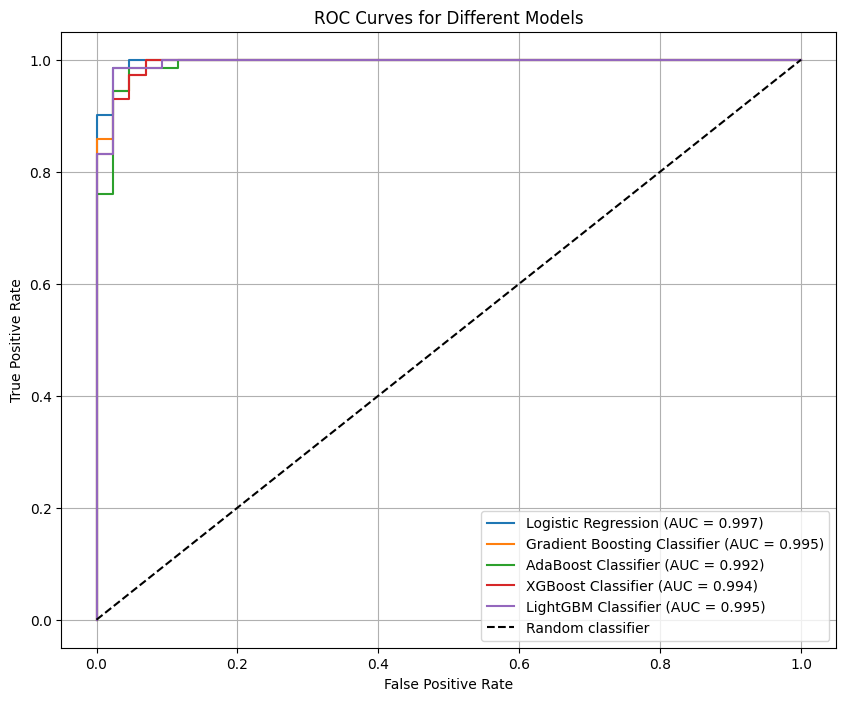

In [14]:
# For each model, plot the ROC on the same graph
plt.figure(figsize=(10, 8))
for name, model in best_models.items():
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.title("ROC Curves for Different Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()

All models achieve strong performance, with **ROC-AUC scores above 0.99**, indicating excellent discrimination ability. 

Logistic Regression and LightGBM stand out with the highest accuracy and F1-score, while **AdaBoost and Logistic Regression achieve the best recall** (≈0.986), which is critical in this medical context to **minimize false negatives** (i.e., missed cancer cases).

Interestingly, boosting models (Gradient Boosting, XGBoost, LightGBM) do not significantly outperform Logistic Regression, suggesting that the **dataset is relatively simple** and mostly linearly separable. While LightGBM matches Logistic Regression in performance, it does not provide a substantial gain despite higher computational cost and lower interpretability.

Overall, **Logistic Regression** appears to be the **best trade-off between performance, interpretability, and efficiency**. In a real-world medical setting, its high recall and transparency make it a strong candidate, while boosting models may still be useful when maximizing predictive performance is the primary objective.

## 7. Feature importance

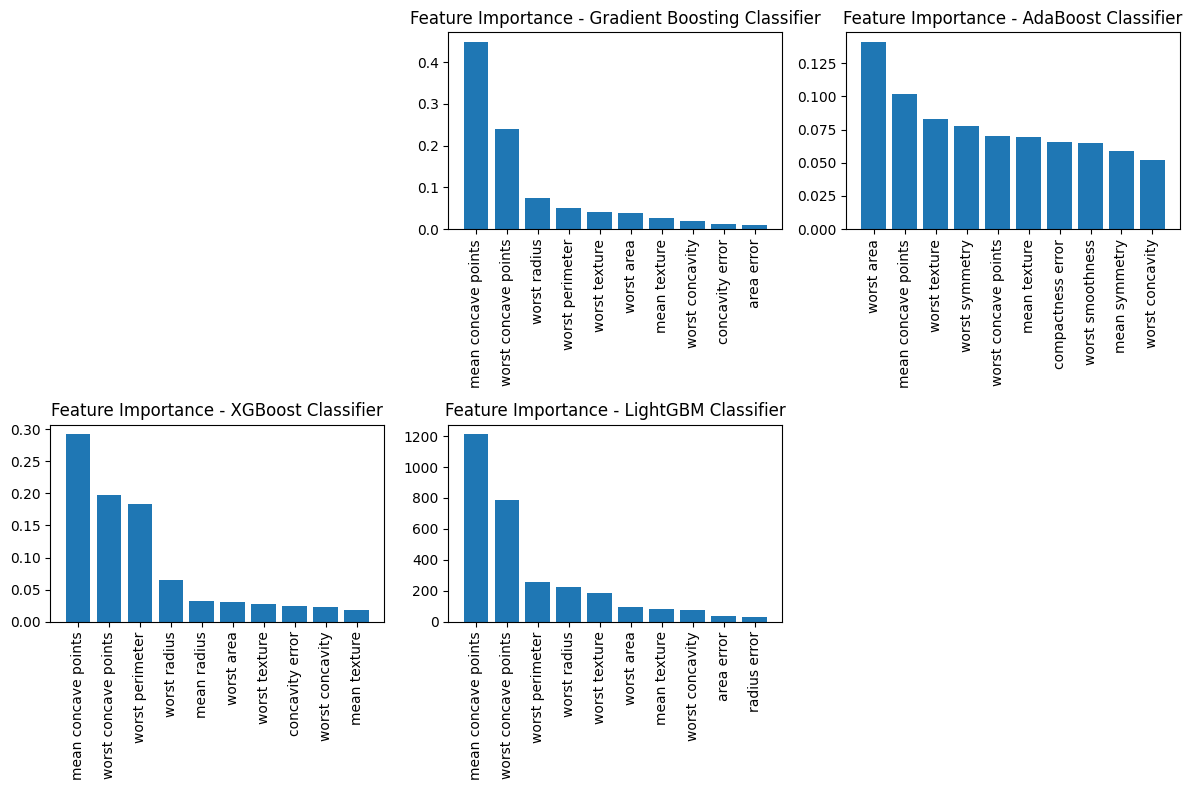

In [16]:
# For each model, plot the feature importance with a bar chart (10 most important features)
plt.figure(figsize=(12, 8))
for i, (name, model) in enumerate(best_models.items()):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        plt.subplot(2, 3, i + 1)
        plt.bar(range(10), importances[indices[:10]], align="center")
        plt.xticks(range(10), data.feature_names[indices[:10]], rotation=90)
        plt.title(f"Feature Importance - {name}")
        plt.tight_layout()
plt.show()

GBM, XGBoost, and LightGBM consistently identify *mean concave points* and *worst concave points* as the **most discriminative features**. This convergence is a strong signal: when different algorithms agree on the same features, it likely reflects a genuine pattern in the data rather than a modeling artifact.

AdaBoost, however, diverges by ranking *worst area* as the most important feature. This difference can be explained by its use of decision stumps (depth-1 trees), which capture simpler, one-level splits and do not combine features across multiple tree levels like other boosting methods.

Finally, **GBM shows a highly concentrated importance distribution**, where **two features account for nearly 70% of the total importance**. In contrast, **XGBoost and LightGBM distribute importance across 4–5 features**. A more distributed importance is generally associated with greater robustness, as the model is less sensitive to the removal or noise in any single feature.

## 8. Conclusion

This study shows that **all models achieve excellent performance** on the Breast Cancer dataset, with **ROC-AUC scores above 0.99** and very small differences across methods. **Boosting algorithms** (Gradient Boosting, XGBoost, LightGBM) **converge toward similar hyperparameters**, indicating that the problem is relatively simple and mostly linearly separable (breast cancer is a small and clean dataset with only 562 examples, small noise). As a result, they provide only marginal improvements over **Logistic Regression**, which already performs at a very high level.

From a practical standpoint, **Logistic Regression emerges as the best trade-off between performance, efficiency, and interpretability**. It matches the top-performing models in accuracy and F1-score, achieves one of the **highest recall values** (critical and prioritary in a medical context to minimize false negatives), and trains almost instantly compared to more computationally expensive boosting methods. While LightGBM reaches similar performance, it does not justify its higher complexity and lower interpretability on this dataset.

Finally, **feature importance analysis** reveals consistent patterns across models: GBM, XGBoost, and LightGBM all identify *mean concave points* and *worst concave points* as the most discriminative features, reinforcing their relevance as true signals in the data. Differences in importance distribution also highlight trade-offs in robustness, with XGBoost and LightGBM relying on a broader set of features, while GBM concentrates most of its predictive power on a few variables. Overall, this study emphasizes that model simplicity, interpretability, and domain constraints should guide model selection as much as raw performance.